In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup and Imports

In [2]:
import os
import sys
import json
import math
import copy
import logging
import h5py
import numpy as np
import healpy as hp
import lenspyx
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# Suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, Flatten, Add, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Add deepsphere path if needed
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

from mlpng import Core
from mlpng.utils import get_data, setup_logging
from mlpng.utils.dataloaders import MapDataset, KappaDataset

# Setup logging
logger = setup_logging("mlpng.double_model", level=logging.DEBUG)

# Set plot style
plt.style.use("seaborn-v0_8-paper")
plt.rc("font", family="serif")
plt.rc("figure", figsize=(12, 8))

print("TensorFlow version:", tf.__version__)
print("GPUs available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.15.1
GPUs available: 1


## Load Settings and Configuration

In [3]:
# Initialize Core object with settings
core = Core(
    [
        "settings/n64.json",
        "--nsims",
        "10000",
        "--shapes",
        "local",
        "--fnl_range",
        "-1000",
        "1000",
    ]
)

# Extract parameters from core
nside = core.nside
nsims = core.nsims
npix = hp.nside2npix(nside)
npols = core.npols if hasattr(core, "npols") else 1
shapes = core.shapes
nshapes = len(shapes)

21-Nov-25 12:33:00 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n64.json', '--nsims', '10000', '--shapes', 'local', '--fnl_range', '-1000', '1000']
21-Nov-25 12:33:00 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
21-Nov-25 12:33:00 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 10000,
  "nside": 64,
  "fnl_range": [
    -1000,
   

## Model Architecture - DualParameterModel

This model uses a ResidualHealpyUNet encoder (without decoder) followed by separate dense networks for fnl and phi_scales prediction.

In [4]:
@tf.keras.saving.register_keras_serializable()
class EncoderBlock(tf.keras.layers.Layer):
    """Encoder block using HEALPix convolutions."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        activation,
        max_batch_size,
        K,
        use_bn=True,
        use_bias=False,
        pool=True,
        dropout_rate=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.nside = nside
        self.npix = npix
        self.fin = fin
        self.fout = fout
        self.activation_fn = activation
        self.max_batch_size = max_batch_size
        self.K = K
        self.use_bn = use_bn
        self.use_bias = use_bias
        self.dropout_rate = dropout_rate
        self.pool = pool
        indices = np.arange(npix)

        enc_layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
        ]
        if dropout_rate > 0.0:
            enc_layers.append(Dropout(dropout_rate))

        self.body = HealpyGCNN(
            nside=nside,
            indices=indices,
            layers=enc_layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

        self.pooler = None
        if pool:
            self.pooler = HealpyGCNN(
                nside=nside,
                indices=indices,
                layers=[HealpyPool(1, "AVG")],
                n_neighbors=8,
                max_batch_size=max_batch_size,
                initial_Fin=fout,
            )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "nside": self.nside,
                "npix": self.npix,
                "fin": self.fin,
                "fout": self.fout,
                "activation": self.activation_fn,
                "max_batch_size": self.max_batch_size,
                "K": self.K,
                "use_bn": self.use_bn,
                "use_bias": self.use_bias,
                "pool": self.pool,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

    def call(self, inputs, training=False):
        x = self.body(inputs, training=training)
        if self.pool:
            x = self.pooler(x, training=training)
        return x


def create_dual_parameter_model(input_shape, nshapes=3, max_batch_size=32):
    """
    Create a dual-parameter prediction model with separate outputs for fnl and phi_scale.

    Args:
        input_shape: Tuple (batch, npix, npols)
        nshapes: Number of fnl shape parameters (default: 3 for local, equilateral, orthogonal)
        max_batch_size: Maximum batch size for HEALPix operations

    Returns:
        Compiled Keras model with separate loss tracking for each output
    """
    npix = input_shape[1]
    npol = input_shape[2]
    nside = hp.npix2nside(npix)

    # Calculate encoder depth based on nside
    depth = int(math.log2(nside))

    # Channel progression: [npol, 8, 16, 32, 64, 128, ...]
    base_channels = [npol] + [2 ** (i + 4) for i in range(depth)]
    level_npixels = [npix // (4**i) for i in range(depth + 1)]
    level_nsides = [hp.npix2nside(pix) for pix in level_npixels]

    # Chebyshev order progression: [1, 3, 5, 7, ...]
    Ks = [3 + (2 * (i // 2)) for i in range(depth + 1)]

    # Build model
    inputs = Input(shape=input_shape[1:], name="lensed")
    x = inputs

    # Encoder blocks
    for i in range(depth):
        block = EncoderBlock(
            level_nsides[i],
            level_npixels[i],
            fin=base_channels[i],
            fout=base_channels[i + 1],
            activation="gelu",
            max_batch_size=max_batch_size,
            K=Ks[i],
            dropout_rate=0.1,
            use_bias=True,
            use_bn=True,
        )
        x = block(x)

    # Flatten the encoder output
    x = Flatten()(x)

    # Dense network for fnl prediction
    fnl_branch = Dense(32, activation="relu", name="fnl_dense1")(x)
    fnl_branch = Dense(32, activation="relu", name="fnl_dense2")(fnl_branch)
    # fnl_branch = Dropout(0.1)(fnl_branch)
    fnl_output = Dense(nshapes, name="fnl")(fnl_branch)

    # Dense network for phi_scales prediction
    x = Dropout(0.1)(x)
    phi_branch = Dense(512, activation="relu", name="phi_dense1")(x)
    phi_branch = Dense(256, activation="relu", name="phi_dense2")(phi_branch)
    phi_branch = layers.BatchNormalization()(phi_branch)
    phi_branch = Dense(32, activation="relu", name="phi_dense3")(phi_branch)
    phi_branch = Dense(32, activation="relu", name="phi_dense4")(phi_branch)
    phi_output = Dense(1, name="phi_scale")(phi_branch)

    # Create model with separate outputs
    model = Model(
        inputs=inputs, outputs=[fnl_output, phi_output], name="DualParameterModel"
    )

    return model

## Dataset Creation and Pipeline Setup

In [5]:
# Create dataset using KappaDataset for dual-parameter prediction
# KappaDataset handles lensing with phi_scale-dependent potential
dataset = KappaDataset.fromCore(
    core,
    phi_scale=(0.0, 100.0),  # Uniformly sample phi_scale from [0, 100]
    kappa_scale=np.sqrt(1e7),
    x_output="kappa",  # Use lensed maps
    y_output=("fnl", "phi_scale"),  # Output both fnl and phi_scale as dict keys
    gaussian_mask_prob=0.1,  # Probabilistically mask fnl and phi_scale
)

21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Error information from 'data/data/l191_n64_T_10000_p1.0.hdf5'...
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276


In [6]:
# Split dataset into train/val/test with 80/10/10 distribution and duplications
# KappaDataset returns dicts: x_dict with "lensed" and y_dict with "fnl", "phi_scale"
train_ds, val_ds, test_ds = dataset.split(
    batch_size=64,
    train_size=0.08,
    val_size=0.01,
    test_size=0.01,
    to_tf=True,
    duplicates=[25, 10, 2],
    gaussian_mask=[True, False, False],
)

21-Nov-25 12:33:01 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/l191_n64_T_10000_p1.0.hdf5' into train: 0:800 (800), val: 800:900 (100), test: 900:1000 (100)


## Distributed Training Setup

In [7]:
# Initialize MirroredStrategy for multi-GPU training
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
21-Nov-25 12:33:02 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1
21-Nov-25 12:33:02 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1


## Model Definition and Compilation

In [8]:
# Create and compile model within strategy scope for distributed training
with strategy.scope():
    input_shape = (None, npix * 4, npols)
    nshapes = len(dataset.shapes)

    model = create_dual_parameter_model(
        input_shape=input_shape, nshapes=nshapes, max_batch_size=32
    )

    model.summary()

    # Compile model with separate losses for each output
    epochs = 50
    initial_learning_rate = 1e-3

    # Calculate decay steps based on training dataset size
    train_samples = int(10000 * 0.08 * 25)  # 80% of 10k with 25x duplication
    batch_size = 32  # Default batch size
    steps_per_epoch = math.ceil(train_samples / batch_size)
    decay_steps = steps_per_epoch * 3  # Decay over 3 epochs

    # Create learning rate schedule with exponential decay
    lr_schedule = ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        decay_rate=0.95,
        staircase=True,
    )

    # Compile with separate losses for fnl and phi_scale outputs
    # This allows TensorFlow to track loss for each output separately
    model.compile(
        optimizer=AdamW(learning_rate=lr_schedule),
        loss={"fnl": "mse", "phi_scale": "mse"},
        loss_weights={"fnl": 1.0, "phi_scale": 1.0},
    )

print("Model created and compiled with separate losses for fnl and phi_scale outputs")

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
21-Nov-25 12:33:14 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
21-Nov-25 12:33:14 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
21-Nov-25 12:33:14 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
21-Nov-25 12:33:14 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/de

## Model Training

In [9]:
# Force data generation to cache by iterating through all datasets
print("Generating and caching data with direct ALM lensing...")
for _ in train_ds:
    pass

for _ in val_ds:
    pass

for _ in test_ds:
    pass

Generating and caching data with direct ALM lensing...


In [10]:
# Setup callbacks
checkpoint_dir = os.path.join(core.dirs.get("model", "./checkpoints"), "dual_param")
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
    ),
]

# Train model with separate targets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50


I0000 00:00:1763750098.262172  683384 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 [==============================] - 223s 681ms/step - loss: 299184.4375 - fnl_loss: 298202.5000 - phi_scale_loss: 982.0246 - val_loss: 305858.5938 - val_fnl_loss: 305638.4688 - val_phi_scale_loss: 220.1496
Epoch 2/50
313/313 [==============================] - 212s 678ms/step - loss: 298720.1562 - fnl_loss: 298226.4688 - phi_scale_loss: 493.6505 - val_loss: 305309.9375 - val_fnl_loss: 305050.1875 - val_phi_scale_loss: 259.7903
Epoch 3/50
313/313 [==============================] - 212s 678ms/step - loss: 298576.6250 - fnl_loss: 298175.8438 - phi_scale_loss: 400.9054 - val_loss: 305154.0625 - val_fnl_loss: 304868.1562 - val_phi_scale_loss: 285.8854
Epoch 4/50
313/313 [==============================] - 212s 678ms/step - loss: 298568.3125 - fnl_loss: 298204.8750 - phi_scale_loss: 363.3981 - val_loss: 305151.0625 - val_fnl_loss: 304896.3125 - val_phi_scale_loss: 254.7321
Epoch 5/50
313/313 [==============================] - 212s 678ms/step - loss: 298483.5625 - fnl_loss: 298142.7188 -

## Training Curves

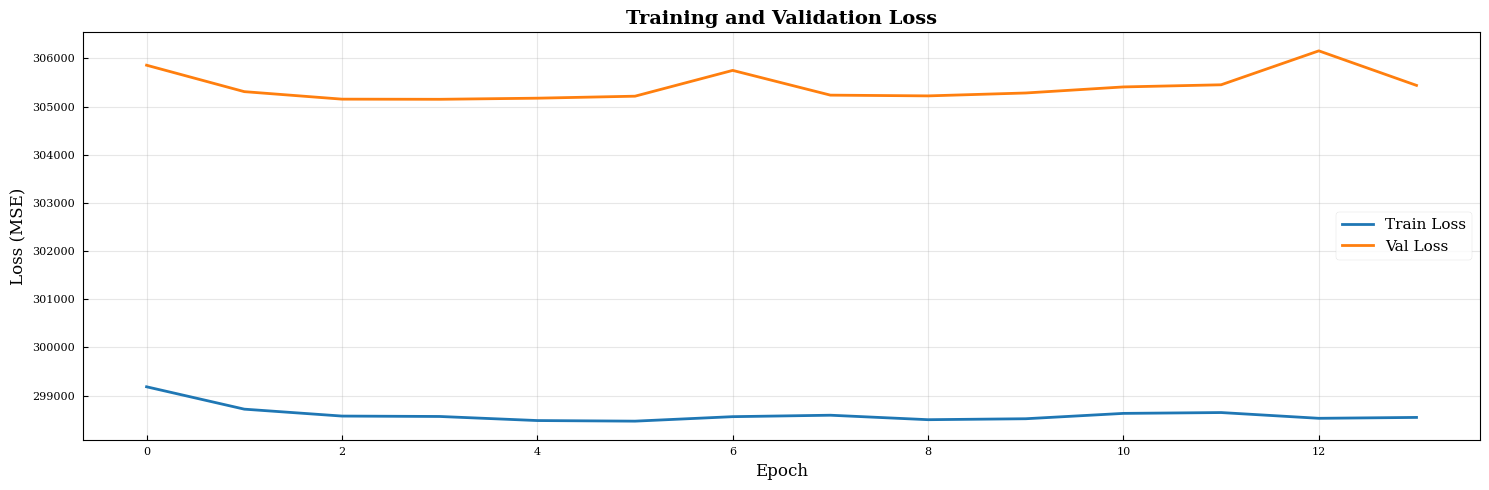

In [11]:
# Plot training curves
if "history" in locals():
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    # Plot loss
    ax.plot(history.history["loss"], label="Train Loss", linewidth=2)
    ax.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss (MSE)", fontsize=12)
    ax.set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Training history not available. Train the model first.")

## Model Evaluation and Predictions

In [12]:
# Make predictions on test set
y_fnl_true_list = []
y_phi_true_list = []
y_fnl_pred_list = []
y_phi_pred_list = []

for batch_x, batch_y in test_ds:
    fnl_pred, phi_pred = model.predict(batch_x, verbose=0)
    y_fnl_true_list.append(batch_y["fnl"].numpy())
    y_phi_true_list.append(batch_y["phi_scale"].numpy())
    y_fnl_pred_list.append(fnl_pred)
    y_phi_pred_list.append(phi_pred)

y_fnl_true = np.concatenate(y_fnl_true_list, axis=0)
y_phi_true = np.concatenate(y_phi_true_list, axis=0)
y_fnl_pred = np.concatenate(y_fnl_pred_list, axis=0)
y_phi_pred = np.concatenate(y_phi_pred_list, axis=0)

print("=" * 60)
print("Performance Metrics")
print("=" * 60)

# fnl metrics (one per shape)
for i, shape in enumerate(dataset.shapes):
    mae = np.mean(np.abs(y_fnl_true[:, i] - y_fnl_pred[:, i]))
    rmse = np.sqrt(np.mean((y_fnl_true[:, i] - y_fnl_pred[:, i]) ** 2))
    print(f"\nfnl ({shape}):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")

# phi_scale metrics
mae_phi = np.mean(np.abs(y_phi_true - y_phi_pred))
rmse_phi = np.sqrt(np.mean((y_phi_true - y_phi_pred) ** 2))
print(f"\nphi_scale:")
print(f"  MAE:  {mae_phi:.4f}")
print(f"  RMSE: {rmse_phi:.4f}")

Performance Metrics

fnl (local):
  MAE:  473.5534
  RMSE: 564.5770

phi_scale:
  MAE:  14.2368
  RMSE: 16.3181


## Visualization: True vs Predicted Scatter Plots

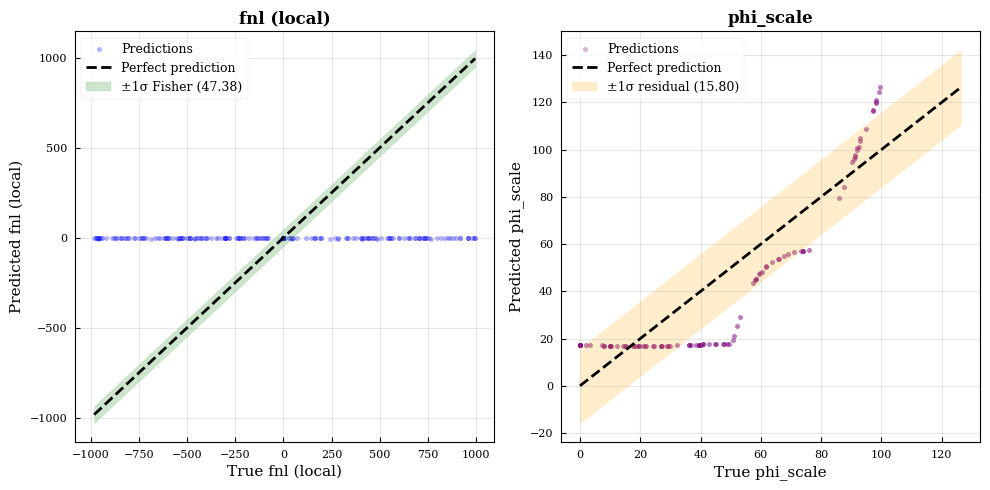

In [13]:
# True vs Predicted scatter plots with separate fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# Plot fnl parameters
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]

    # Calculate residuals
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]
    std_residual = np.std(residuals)

    # Scatter plot
    ax.scatter(
        y_fnl_true[:, i],
        y_fnl_pred[:, i],
        alpha=0.3,
        s=10,
        c="blue",
        label="Predictions",
    )

    # Perfect prediction line
    min_val = min(y_fnl_true[:, i].min(), y_fnl_pred[:, i].min())
    max_val = max(y_fnl_true[:, i].max(), y_fnl_pred[:, i].max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        linewidth=2,
        label="Perfect prediction",
    )

    # Error bands: Use Fisher matrix for fnl
    try:
        fisher = get_data(core.file, f"fisher/{dataset.l_str}/{shape_name}", 0)
        error_band = 1 / np.sqrt(fisher)
        label_band = f"±1σ Fisher ({error_band:.2f})"
        color_band = "green"
    except:
        error_band = std_residual
        label_band = f"±1σ residual ({error_band:.2f})"
        color_band = "red"

    ax.fill_between(
        np.linspace(min_val, max_val, 100),
        np.linspace(min_val, max_val, 100) - error_band,
        np.linspace(min_val, max_val, 100) + error_band,
        alpha=0.2,
        color=color_band,
        label=label_band,
    )

    ax.set_xlabel(f"True fnl ({shape_name})", fontsize=11)
    ax.set_ylabel(f"Predicted fnl ({shape_name})", fontsize=11)
    ax.set_title(f"fnl ({shape_name})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Plot phi_scale
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()
std_residual_phi = np.std(residuals_phi)

ax_phi.scatter(y_phi_true, y_phi_pred, alpha=0.3, s=10, c="purple", label="Predictions")

min_val_phi = min(y_phi_true.min(), y_phi_pred.min())
max_val_phi = max(y_phi_true.max(), y_phi_pred.max())
ax_phi.plot(
    [min_val_phi, max_val_phi],
    [min_val_phi, max_val_phi],
    "k--",
    linewidth=2,
    label="Perfect prediction",
)

ax_phi.fill_between(
    np.linspace(min_val_phi, max_val_phi, 100),
    np.linspace(min_val_phi, max_val_phi, 100) - std_residual_phi,
    np.linspace(min_val_phi, max_val_phi, 100) + std_residual_phi,
    alpha=0.2,
    color="orange",
    label=f"±1σ residual ({std_residual_phi:.2f})",
)

ax_phi.set_xlabel("True phi_scale", fontsize=11)
ax_phi.set_ylabel("Predicted phi_scale", fontsize=11)
ax_phi.set_title("phi_scale", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Residual Distributions

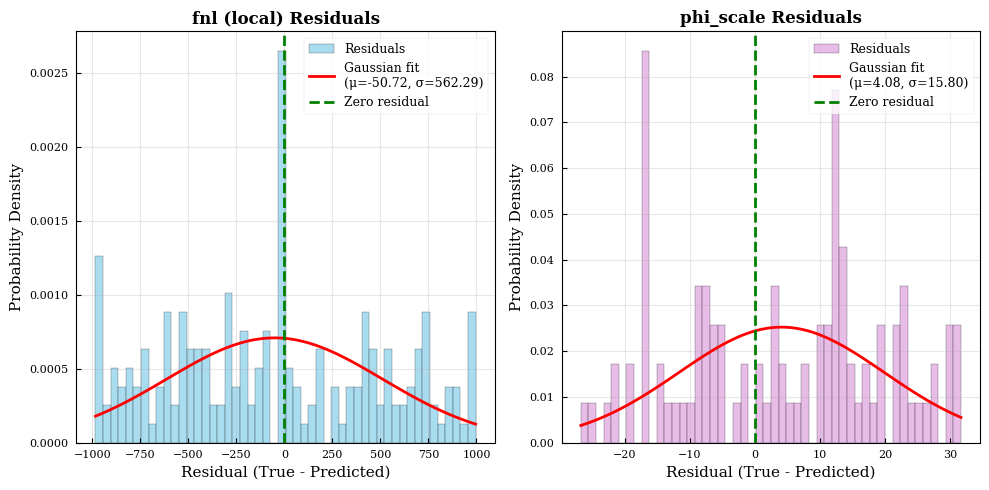

In [14]:
# Residual distributions for fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# fnl residuals
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]

    # Histogram
    n, bins, patches = ax.hist(
        residuals,
        bins=50,
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
        label="Residuals",
    )

    # Fit Gaussian
    mu = np.mean(residuals)
    sigma = np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )
    ax.plot(
        x,
        gaussian,
        "r-",
        linewidth=2,
        label=f"Gaussian fit\n(μ={mu:.2f}, σ={sigma:.2f})",
    )

    ax.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
    ax.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
    ax.set_ylabel("Probability Density", fontsize=11)
    ax.set_title(f"fnl ({shape_name}) Residuals", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# phi_scale residuals
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()

n, bins, patches = ax_phi.hist(
    residuals_phi,
    bins=50,
    density=True,
    alpha=0.7,
    color="plum",
    edgecolor="black",
    label="Residuals",
)

mu_phi = np.mean(residuals_phi)
sigma_phi = np.std(residuals_phi)
x_phi = np.linspace(residuals_phi.min(), residuals_phi.max(), 100)
gaussian_phi = (1 / (sigma_phi * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_phi - mu_phi) / sigma_phi) ** 2
)
ax_phi.plot(
    x_phi,
    gaussian_phi,
    "r-",
    linewidth=2,
    label=f"Gaussian fit\n(μ={mu_phi:.2f}, σ={sigma_phi:.2f})",
)

ax_phi.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
ax_phi.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
ax_phi.set_ylabel("Probability Density", fontsize=11)
ax_phi.set_title("phi_scale Residuals", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()